In [127]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import numpy as np
from collections import Counter
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## Decision Tree

In [129]:
np.random.seed(42)

In [130]:
def gini(y):
    counts = Counter(y)
    impurity = 1.0
    total = len(y)
    for cls in counts.values():
        p = cls / total
        impurity -= p ** 2
    return impurity

In [131]:
def entropy(y):
    counts = Counter(y)
    total = len(y)
    ent = 0.0
    for c in counts.values():
        p = c / total
        ent -= p * np.log2(p + 1e-9)
    return ent

In [132]:
def split_dataset(X, y, feature_idx, threshold):
    left_mask = X[:, feature_idx] <= threshold
    right_mask = X[:, feature_idx] > threshold
    return X[left_mask], y[left_mask], X[right_mask], y[right_mask]

In [ ]:
# def best_split(X, y, feature_indices):
#     best_gini = float("inf")
#     best_feature = None
#     best_threshold = None

#     for feature in feature_indices:
#         thresholds = np.unique(X[:, feature])
#         for t in thresholds:
#             X_l, y_l, X_r, y_r = split_dataset(X, y, feature, t)
#             if len(y_l) == 0 or len(y_r) == 0:
#                 continue

#             g = (len(y_l) / len(y)) * gini(y_l) + \
#                 (len(y_r) / len(y)) * gini(y_r)

#             if g < best_gini:
#                 best_gini = g
#                 best_feature = feature
#                 best_threshold = t

#     return best_feature, best_threshold

In [137]:
def best_split(X, y, feature_indices, criterion="gini"):
    best_impurity = float("inf")
    best_feature = None
    best_threshold = None

    if criterion == "gini":
        impurity_fn = gini
    else:
        impurity_fn = entropy

    for feature in feature_indices:
        thresholds = np.unique(X[:, feature])
        for t in thresholds:
            X_l, y_l, X_r, y_r = split_dataset(X, y, feature, t)

            if len(y_l) == 0 or len(y_r) == 0:
                continue

            impurity = (
                len(y_l) / len(y) * impurity_fn(y_l)
                + len(y_r) / len(y) * impurity_fn(y_r)
            )

            if impurity < best_impurity:
                best_impurity = impurity
                best_feature = feature
                best_threshold = t

    return best_feature, best_threshold


In [134]:
class TreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

In [138]:
class DecisionTree:
    def __init__(self, max_depth=10, min_samples_split=2, max_features=None, criterion="gini"):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.criterion = criterion
        self.root = None

    def _build_tree(self, X, y, depth):
        num_samples, num_features = X.shape
        num_classes = len(np.unique(y))

        # stopping conditions
        if (self.max_depth is not None and depth >= self.max_depth) \
        or num_samples < self.min_samples_split \
        or num_classes == 1:
            leaf_value = Counter(y).most_common(1)[0][0]
            return TreeNode(value=leaf_value)

        # feature subsampling (for RF later)
        feature_indices = np.arange(num_features)
        if self.max_features:
            feature_indices = np.random.choice(
                num_features, self.max_features, replace=False
            )

        # feature, threshold = best_split(X, y, feature_indices)
        feature, threshold = best_split(
            X, y, feature_indices, criterion=self.criterion
        )
        if feature is None:
            leaf_value = Counter(y).most_common(1)[0][0]
            return TreeNode(value=leaf_value)

        X_l, y_l, X_r, y_r = split_dataset(X, y, feature, threshold)

        left = self._build_tree(X_l, y_l, depth + 1)
        right = self._build_tree(X_r, y_r, depth + 1)

        return TreeNode(feature, threshold, left, right)

    def fit(self, X, y):
        self.root = self._build_tree(X, y, 0)

    def _predict_one(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        return self._predict_one(x, node.right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])


In [154]:
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
X.shape

(150, 4)

In [11]:
y.shape

(150,)

In [12]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [13]:
print("First training sample:", X_train[0])
print("Its label:", y_train[0])

First training sample: [4.6 3.6 1.  0.2]
Its label: 0


In [14]:
print("Train class distribution:", Counter(y_train))
print("Test class distribution:", Counter(y_test))

Train class distribution: Counter({np.int64(1): 41, np.int64(0): 40, np.int64(2): 39})
Test class distribution: Counter({np.int64(2): 11, np.int64(0): 10, np.int64(1): 9})


In [155]:
dt = DecisionTree(max_depth=5)
dt.fit(X_train, y_train)
preds = dt.predict(X_test)

In [156]:
y_test_bin = label_binarize(y_test, classes=np.unique(y))
preds_bin = label_binarize(preds, classes=np.unique(y))

In [157]:
print("Accuracy:", accuracy_score(y_test, preds))
print("F1-score:", f1_score(y_test, preds, average="macro"))
print("AUROC:", roc_auc_score(y_test_bin, preds_bin, multi_class="ovr"))

Accuracy: 1.0
F1-score: 1.0
AUROC: 1.0


In [144]:
X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [151]:
dt = DecisionTree(max_depth=5)
dt.fit(X_train, y_train)
preds = dt.predict(X_test)

In [152]:
y_test_bin = label_binarize(y_test, classes=np.unique(y))
preds_bin = label_binarize(preds, classes=np.unique(y))

In [153]:
print("Accuracy:", accuracy_score(y_test, preds))
print("F1-score:", f1_score(y_test, preds, average="macro"))
print("AUROC:", roc_auc_score(y_test_bin, preds_bin, multi_class="ovr"))

Accuracy: 0.9166666666666666
F1-score: 0.9194854953475643
AUROC: 0.9326298701298702


## Random Forest

In [158]:
class RandomForest:
    def __init__(self, n_trees=10, max_depth=10, min_samples_split=2, max_features=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        for _ in range(self.n_trees):
            # Bootstrap sample
            indices = np.random.choice(len(X), len(X), replace=True)
            X_sample = X[indices]
            y_sample = y[indices]

            # Train tree
            tree = DecisionTree(max_depth=self.max_depth,
                                min_samples_split=self.min_samples_split,
                                max_features=self.max_features)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        preds_all = np.array([tree.predict(X) for tree in self.trees])
        final_preds = []
        for i in range(X.shape[0]):
            counts = Counter(preds_all[:, i])
            final_preds.append(counts.most_common(1)[0][0])
        return np.array(final_preds)

In [159]:
rf = RandomForest(n_trees=2, max_depth=2, max_features=2)
rf.fit(X_train, y_train)
preds_rf = rf.predict(X_test)

In [160]:
y_test_bin = label_binarize(y_test, classes=np.unique(y))
preds_rf_bin = label_binarize(preds_rf, classes=np.unique(y))

In [161]:
print("RF Accuracy:", accuracy_score(y_test, preds_rf))
print("RF F1-score:", f1_score(y_test, preds_rf, average="macro"))
print("RF AUROC:", roc_auc_score(y_test_bin, preds_rf_bin, multi_class="ovr"))

RF Accuracy: 0.9666666666666667
RF F1-score: 0.9665831244778612
RF AUROC: 0.976911976911977


## Extremely Randomized Tree

In [162]:
class ExtraTree:
    def __init__(self, max_depth=None, min_samples_split=2, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.root = None

    def _build_tree(self, X, y, depth):
        num_samples, num_features = X.shape
        num_classes = len(np.unique(y))

        # stopping conditions
        if (self.max_depth and depth >= self.max_depth) or \
           num_samples < self.min_samples_split or \
           num_classes == 1:
            leaf_value = Counter(y).most_common(1)[0][0]
            return TreeNode(value=leaf_value)

        # feature subsampling
        feature_indices = np.arange(num_features)
        if self.max_features:
            feature_indices = np.random.choice(
                num_features, self.max_features, replace=False
            )

        # choose **random thresholds** for each candidate feature
        best_gini = float("inf")
        best_feature = None
        best_threshold = None
        for feature in feature_indices:
            f_min, f_max = X[:, feature].min(), X[:, feature].max()
            # sample a random threshold in [min, max]
            threshold = np.random.uniform(f_min, f_max)
            X_l, y_l, X_r, y_r = split_dataset(X, y, feature, threshold)
            if len(y_l) == 0 or len(y_r) == 0:
                continue

            g = (len(y_l)/len(y))*gini(y_l) + (len(y_r)/len(y))*gini(y_r)
            if g < best_gini:
                best_gini = g
                best_feature = feature
                best_threshold = threshold

        if best_feature is None:
            leaf_value = Counter(y).most_common(1)[0][0]
            return TreeNode(value=leaf_value)

        X_l, y_l, X_r, y_r = split_dataset(X, y, best_feature, best_threshold)
        left = self._build_tree(X_l, y_l, depth + 1)
        right = self._build_tree(X_r, y_r, depth + 1)
        return TreeNode(best_feature, best_threshold, left, right)

    def fit(self, X, y):
        self.root = self._build_tree(X, y, 0)

    def _predict_one(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        return self._predict_one(x, node.right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])

In [163]:
class ExtraTrees:
    def __init__(self, n_estimators=100, max_depth=None, min_samples_split=2, max_features=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        np.random.seed(42)  # fix randomness
        for _ in range(self.n_estimators):
            tree = ExtraTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=self.max_features
            )
            # no bootstrap by default
            tree.fit(X, y)
            self.trees.append(tree)

    def predict(self, X):
        # aggregate predictions by majority vote
        all_preds = np.array([tree.predict(X) for tree in self.trees])
        # transpose: shape (n_samples, n_trees)
        all_preds = all_preds.T
        final_preds = []
        for sample_preds in all_preds:
            most_common = Counter(sample_preds).most_common(1)[0][0]
            final_preds.append(most_common)
        return np.array(final_preds)

In [164]:
X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [165]:
et = ExtraTrees(n_estimators=50, max_depth=5, max_features=int(np.sqrt(X.shape[1])))
et.fit(X_train, y_train)
preds = et.predict(X_test)

In [166]:
y_test_bin = label_binarize(y_test, classes=np.unique(y))
preds_bin = label_binarize(preds, classes=np.unique(y))

In [167]:
print("Extra Trees Accuracy:", accuracy_score(y_test, preds))
print("Extra Trees F1-score:", f1_score(y_test, preds, average="macro"))
print("Extra Trees AUROC:", roc_auc_score(y_test_bin, preds_bin, multi_class="ovr"))

Extra Trees Accuracy: 0.9722222222222222
Extra Trees F1-score: 0.974320987654321
Extra Trees AUROC: 0.9811507936507936


In [168]:
def evaluate_models(X_train, X_test, y_train, y_test, max_depth=5, n_estimators=50):
    results = []

    # --- Decision Tree ---
    dt = DecisionTree(max_depth=max_depth)
    dt.fit(X_train, y_train)
    preds_dt = dt.predict(X_test)
    y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
    preds_dt_bin = label_binarize(preds_dt, classes=np.unique(y_test))
    results.append({
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_test, preds_dt),
        "F1": f1_score(y_test, preds_dt, average="macro"),
        "AUROC": roc_auc_score(y_test_bin, preds_dt_bin, multi_class="ovr")
    })

    # --- Random Forest ---
    rf = RandomForest(n_trees=n_estimators, max_depth=max_depth,
                      max_features=int(np.sqrt(X_train.shape[1])))
    rf.fit(X_train, y_train)
    preds_rf = rf.predict(X_test)
    preds_rf_bin = label_binarize(preds_rf, classes=np.unique(y_test))
    results.append({
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, preds_rf),
        "F1": f1_score(y_test, preds_rf, average="macro"),
        "AUROC": roc_auc_score(y_test_bin, preds_rf_bin, multi_class="ovr")
    })

    # --- Extra Trees ---
    et = ExtraTrees(n_estimators=n_estimators, max_depth=max_depth,
                    max_features=int(np.sqrt(X_train.shape[1])))
    et.fit(X_train, y_train)
    preds_et = et.predict(X_test)
    preds_et_bin = label_binarize(preds_et, classes=np.unique(y_test))
    results.append({
        "Model": "Extra Trees",
        "Accuracy": accuracy_score(y_test, preds_et),
        "F1": f1_score(y_test, preds_et, average="macro"),
        "AUROC": roc_auc_score(y_test_bin, preds_et_bin, multi_class="ovr")
    })

    # --- Print results in a table ---
    print(f"{'Model':<15} {'Accuracy':<10} {'F1':<10} {'AUROC':<10}")
    print("-"*50)
    for r in results:
        print(f"{r['Model']:<15} {r['Accuracy']:<10.4f} {r['F1']:<10.4f} {r['AUROC']:<10.4f}")

    return results

In [169]:
X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

evaluate_models(X_train, X_test, y_train, y_test, max_depth=5, n_estimators=50)

Model           Accuracy   F1         AUROC     
--------------------------------------------------
Decision Tree   0.9167     0.9230     0.9408    
Random Forest   0.9722     0.9743     0.9812    
Extra Trees     0.9722     0.9743     0.9812    


[{'Model': 'Decision Tree',
  'Accuracy': 0.9166666666666666,
  'F1': 0.9229629629629629,
  'AUROC': 0.9408369408369408},
 {'Model': 'Random Forest',
  'Accuracy': 0.9722222222222222,
  'F1': 0.974320987654321,
  'AUROC': 0.9811507936507936},
 {'Model': 'Extra Trees',
  'Accuracy': 0.9722222222222222,
  'F1': 0.974320987654321,
  'AUROC': 0.9811507936507936}]

In [175]:
def evaluate_all_models(X_train, X_test, y_train, y_test, max_depth=5, n_trees=50):
    results = []

    # --- 1. Custom Decision Tree ---
    dt = DecisionTree(max_depth=max_depth)
    dt.fit(X_train, y_train)
    preds_dt = dt.predict(X_test)
    y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
    preds_dt_bin = label_binarize(preds_dt, classes=np.unique(y_test))
    results.append({
        "Model": "Custom Decision Tree",
        "Accuracy": accuracy_score(y_test, preds_dt),
        "F1": f1_score(y_test, preds_dt, average="macro"),
        "AUROC": roc_auc_score(y_test_bin, preds_dt_bin, multi_class="ovr")
    })
    
    # --- 2. scikit-learn Decision Tree ---
    dt_sk = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    dt_sk.fit(X_train, y_train)
    preds_dt_sk = dt_sk.predict(X_test)
    preds_dt_sk_bin = label_binarize(preds_dt_sk, classes=np.unique(y_test))
    results.append({
        "Model": "sklearn Decision Tree",
        "Accuracy": accuracy_score(y_test, preds_dt_sk),
        "F1": f1_score(y_test, preds_dt_sk, average="macro"),
        "AUROC": roc_auc_score(y_test_bin, preds_dt_sk_bin, multi_class="ovr")
    })

    # --- 3. Custom Random Forest ---
    rf = RandomForest(n_trees=n_trees, max_depth=max_depth,
                      max_features=int(np.sqrt(X_train.shape[1])))
    rf.fit(X_train, y_train)
    preds_rf = rf.predict(X_test)
    preds_rf_bin = label_binarize(preds_rf, classes=np.unique(y_test))
    results.append({
        "Model": "Custom Random Forest",
        "Accuracy": accuracy_score(y_test, preds_rf),
        "F1": f1_score(y_test, preds_rf, average="macro"),
        "AUROC": roc_auc_score(y_test_bin, preds_rf_bin, multi_class="ovr")
    })
    
    # --- 4. scikit-learn Random Forest ---
    rf_sk = RandomForestClassifier(n_estimators=n_trees, max_depth=max_depth,
                                   max_features="sqrt", random_state=42)
    rf_sk.fit(X_train, y_train)
    preds_rf_sk = rf_sk.predict(X_test)
    preds_rf_sk_bin = label_binarize(preds_rf_sk, classes=np.unique(y_test))
    results.append({
        "Model": "sklearn Random Forest",
        "Accuracy": accuracy_score(y_test, preds_rf_sk),
        "F1": f1_score(y_test, preds_rf_sk, average="macro"),
        "AUROC": roc_auc_score(y_test_bin, preds_rf_sk_bin, multi_class="ovr")
    })


    # --- 5. Custom Extra Trees ---
    et = ExtraTrees(n_estimators=n_trees, max_depth=max_depth,
                    max_features=int(np.sqrt(X_train.shape[1])))
    et.fit(X_train, y_train)
    preds_et = et.predict(X_test)
    preds_et_bin = label_binarize(preds_et, classes=np.unique(y_test))
    results.append({
        "Model": "Custom Extra Trees",
        "Accuracy": accuracy_score(y_test, preds_et),
        "F1": f1_score(y_test, preds_et, average="macro"),
        "AUROC": roc_auc_score(y_test_bin, preds_et_bin, multi_class="ovr")
    })

    

    
    # --- 6. scikit-learn Extra Trees ---
    et_sk = ExtraTreesClassifier(n_estimators=n_trees, max_depth=max_depth,
                                 max_features="sqrt", random_state=42)
    et_sk.fit(X_train, y_train)
    preds_et_sk = et_sk.predict(X_test)
    preds_et_sk_bin = label_binarize(preds_et_sk, classes=np.unique(y_test))
    results.append({
        "Model": "sklearn Extra Trees",
        "Accuracy": accuracy_score(y_test, preds_et_sk),
        "F1": f1_score(y_test, preds_et_sk, average="macro"),
        "AUROC": roc_auc_score(y_test_bin, preds_et_sk_bin, multi_class="ovr")
    })

    # --- Print table ---
    print(f"{'Model':<25} {'Accuracy':<10} {'F1':<10} {'AUROC':<10}")
    print("-"*60)
    for r in results:
        print(f"{r['Model']:<25} {r['Accuracy']:<10.4f} {r['F1']:<10.4f} {r['AUROC']:<10.4f}")

    return results

In [201]:
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

evaluate_all_models(X_train, X_test, y_train, y_test, max_depth=None, n_trees=500)

Model                     Accuracy   F1         AUROC     
------------------------------------------------------------
Custom Decision Tree      0.9333     0.9333     0.9500    
sklearn Decision Tree     0.9333     0.9333     0.9500    
Custom Random Forest      0.9667     0.9666     0.9750    
sklearn Random Forest     0.9333     0.9333     0.9500    
Custom Extra Trees        0.9667     0.9666     0.9750    
sklearn Extra Trees       0.9667     0.9666     0.9750    


[{'Model': 'Custom Decision Tree',
  'Accuracy': 0.9333333333333333,
  'F1': 0.9333333333333332,
  'AUROC': 0.9499999999999998},
 {'Model': 'sklearn Decision Tree',
  'Accuracy': 0.9333333333333333,
  'F1': 0.9333333333333332,
  'AUROC': 0.9499999999999998},
 {'Model': 'Custom Random Forest',
  'Accuracy': 0.9666666666666667,
  'F1': 0.9665831244778612,
  'AUROC': 0.975},
 {'Model': 'sklearn Random Forest',
  'Accuracy': 0.9333333333333333,
  'F1': 0.9333333333333332,
  'AUROC': 0.9499999999999998},
 {'Model': 'Custom Extra Trees',
  'Accuracy': 0.9666666666666667,
  'F1': 0.9665831244778612,
  'AUROC': 0.975},
 {'Model': 'sklearn Extra Trees',
  'Accuracy': 0.9666666666666667,
  'F1': 0.9665831244778612,
  'AUROC': 0.975}]

In [182]:
results_iris = evaluate_all_models(X_train, X_test, y_train, y_test, max_depth=None, n_trees=500)

Model                     Accuracy   F1         AUROC     
------------------------------------------------------------
Custom Decision Tree      0.9333     0.9333     0.9500    
sklearn Decision Tree     0.9333     0.9333     0.9500    
Custom Random Forest      0.9667     0.9666     0.9750    
sklearn Random Forest     0.9333     0.9333     0.9500    
Custom Extra Trees        0.9667     0.9666     0.9750    
sklearn Extra Trees       0.9667     0.9666     0.9750    


In [193]:
import matplotlib.pyplot as plt
import numpy as np

def plot_model_comparison(results):
    # Mapping results to the plot structure
    labels = ['DT', 'RF', 'ET']
    metrics = ['Accuracy', 'F1', 'AUROC']
    
    # Extracting values based on the "Model" string in your results list
    manual_vals = {m: [] for m in metrics}
    sklearn_vals = {m: [] for m in metrics}
    
    # Filter and group the data
    for m_type in ["Decision Tree", "Random Forest", "Extra Trees"]:
        for metric in metrics:
            m_key = "F1" if metric == "F1" else metric # Handle F1 vs F1 Score naming
            manual_vals[metric].append(next(r[m_key] for r in results if r['Model'] == f"Custom {m_type}"))
            sklearn_vals[metric].append(next(r[m_key] for r in results if r['Model'] == f"sklearn {m_type}"))

    x = np.arange(len(labels))
    width = 0.35
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, metric in enumerate(metrics):
        ax = axes[i]
        
        # Create bars
        rects1 = ax.bar(x - width/2, manual_vals[metric], width, label='Manual', color="#1E1958", edgecolor='black')
        rects2 = ax.bar(x + width/2, sklearn_vals[metric], width, label='sklearn', color="#0E5706", edgecolor='black')

        # Formatting
        ax.set_title(f'{metric}', fontweight='bold', fontsize=14)
        ax.set_ylabel(metric if metric != "F1" else "F1 Score", fontsize=12)
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_ylim(0.85, 1.02) # Adjusted to match your image scale
        ax.grid(axis='y', linestyle='-', alpha=0.3)
        ax.legend(loc='lower right')

        # Add value labels on top of bars
        def autolabel(rects):
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.3f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3), 
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=10)

        autolabel(rects1)
        autolabel(rects2)

    plt.tight_layout()
    plt.show()


Model                     Accuracy   F1         AUROC     
------------------------------------------------------------
Custom Decision Tree      0.9333     0.9333     0.9500    
sklearn Decision Tree     0.9333     0.9333     0.9500    
Custom Random Forest      0.9667     0.9666     0.9750    
sklearn Random Forest     0.9333     0.9333     0.9500    
Custom Extra Trees        0.9667     0.9666     0.9750    
sklearn Extra Trees       0.9667     0.9666     0.9750    


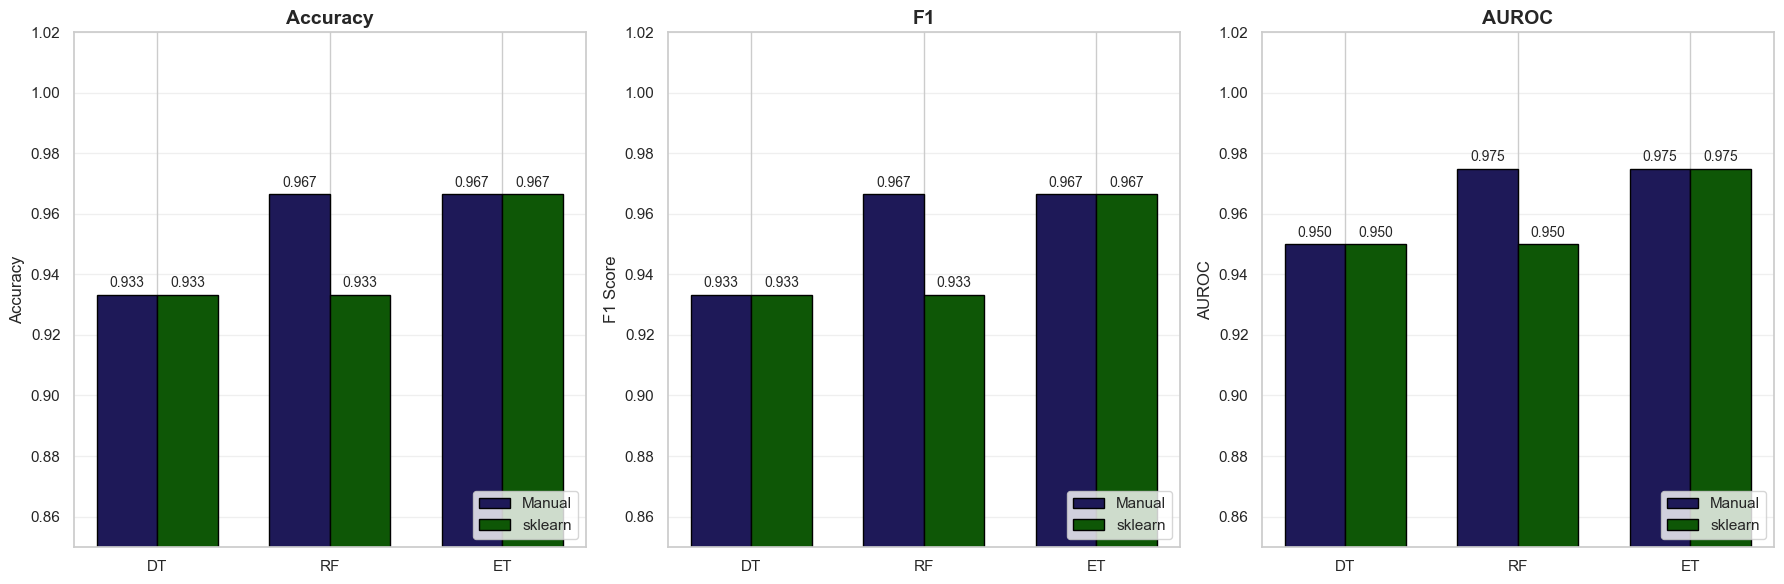

In [194]:
results = evaluate_all_models(X_train, X_test, y_train, y_test, max_depth=None, n_trees=500)
plot_model_comparison(results)

In [210]:
X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

evaluate_all_models(X_train, X_test, y_train, y_test, max_depth=None, n_trees=500)

Model                     Accuracy   F1         AUROC     
------------------------------------------------------------
Custom Decision Tree      0.9167     0.9230     0.9408    
sklearn Decision Tree     0.9444     0.9457     0.9543    
Custom Random Forest      1.0000     1.0000     1.0000    
sklearn Random Forest     1.0000     1.0000     1.0000    
Custom Extra Trees        1.0000     1.0000     1.0000    
sklearn Extra Trees       1.0000     1.0000     1.0000    


[{'Model': 'Custom Decision Tree',
  'Accuracy': 0.9166666666666666,
  'F1': 0.9229629629629629,
  'AUROC': 0.9408369408369408},
 {'Model': 'sklearn Decision Tree',
  'Accuracy': 0.9444444444444444,
  'F1': 0.9457411645054665,
  'AUROC': 0.9542929292929291},
 {'Model': 'Custom Random Forest', 'Accuracy': 1.0, 'F1': 1.0, 'AUROC': 1.0},
 {'Model': 'sklearn Random Forest', 'Accuracy': 1.0, 'F1': 1.0, 'AUROC': 1.0},
 {'Model': 'Custom Extra Trees', 'Accuracy': 1.0, 'F1': 1.0, 'AUROC': 1.0},
 {'Model': 'sklearn Extra Trees', 'Accuracy': 1.0, 'F1': 1.0, 'AUROC': 1.0}]

In [211]:
results_wine = evaluate_all_models(X_train, X_test, y_train, y_test, max_depth=None, n_trees=500)

Model                     Accuracy   F1         AUROC     
------------------------------------------------------------
Custom Decision Tree      0.9167     0.9230     0.9408    
sklearn Decision Tree     0.9444     0.9457     0.9543    
Custom Random Forest      1.0000     1.0000     1.0000    
sklearn Random Forest     1.0000     1.0000     1.0000    
Custom Extra Trees        1.0000     1.0000     1.0000    
sklearn Extra Trees       1.0000     1.0000     1.0000    


Model                     Accuracy   F1         AUROC     
------------------------------------------------------------
Custom Decision Tree      0.9167     0.9230     0.9408    
sklearn Decision Tree     0.9444     0.9457     0.9543    
Custom Random Forest      1.0000     1.0000     1.0000    
sklearn Random Forest     1.0000     1.0000     1.0000    
Custom Extra Trees        1.0000     1.0000     1.0000    
sklearn Extra Trees       1.0000     1.0000     1.0000    


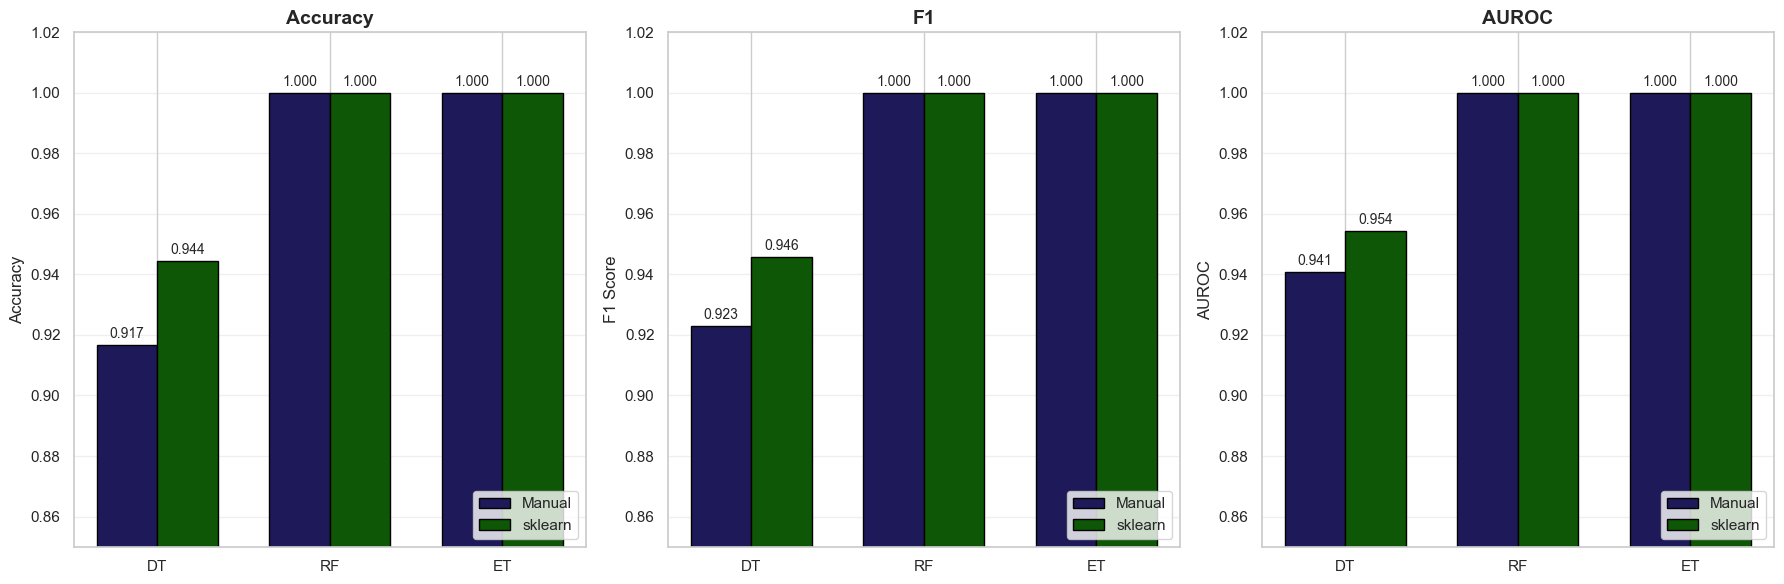

In [196]:
results = evaluate_all_models(X_train, X_test, y_train, y_test, max_depth=None, n_trees=500)
plot_model_comparison(results)

In [202]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Convert your results list to a DataFrame
df = pd.DataFrame(results_iris)
df.set_index('Model', inplace=True)

In [203]:
def plot_heatmap(df, title="Iris Dataset"):
    plt.figure(figsize=(8, 6))
    
    # Using 'RdYlGn' (Red-Yellow-Green) color map to match your image
    sns.heatmap(df, annot=True, fmt=".4f", cmap="RdYlGn", cbar_kws={'label': 'Score'})
    
    plt.title(title, fontweight='bold')
    plt.ylabel('') # Hiding the 'Model' label for a cleaner look
    plt.tight_layout()
    plt.show()

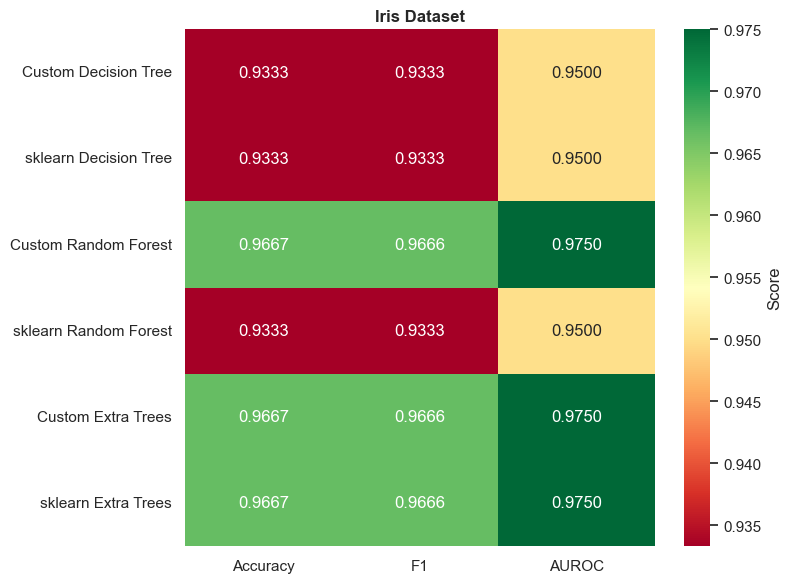

In [205]:
df = pd.DataFrame(results_iris)
df.set_index('Model', inplace=True)
plot_heatmap(df, title="Iris Dataset")

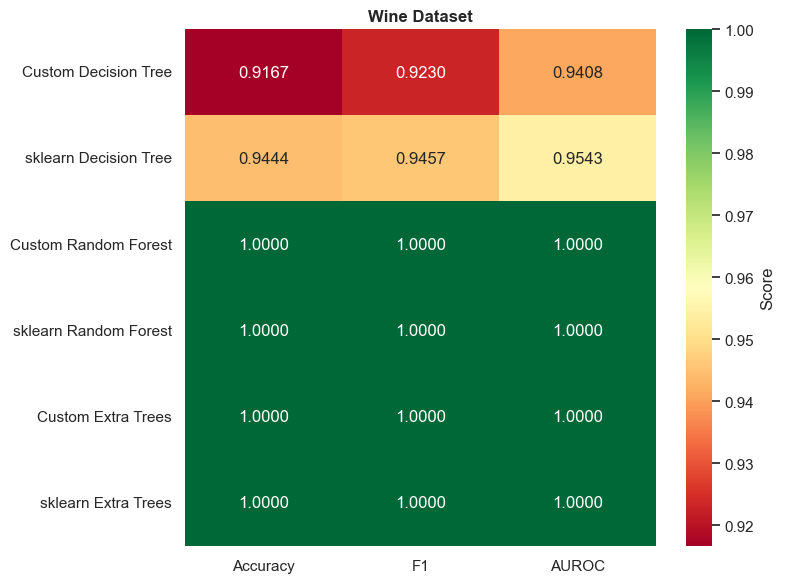

In [212]:
df = pd.DataFrame(results_wine)
df.set_index('Model', inplace=True)
plot_heatmap(df, title="Wine Dataset")

In [213]:
def plot_radar_chart(df, title="Iris Dataset"):
    categories = list(df.columns)
    N = len(categories)
    
    # Prepare the angles for the radar chart
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1] # Close the circle
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    # Draw one axe per variable + add labels
    plt.xticks(angles[:-1], categories)
    
    # Draw y-labels (concentric circles)
    ax.set_rlabel_position(0)
    plt.yticks([0.85, 0.90, 0.95, 1.0], ["0.85", "0.90", "0.95", "1.0"], color="grey", size=8)
    plt.ylim(0.85, 1.02)

    # Plot each model
    for index, row in df.iterrows():
        values = row.values.flatten().tolist()
        values += values[:1] # Close the circle
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=index)
        ax.fill(angles, values, alpha=0.1)

    plt.title(title, size=15, fontweight='bold', y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    plt.show()

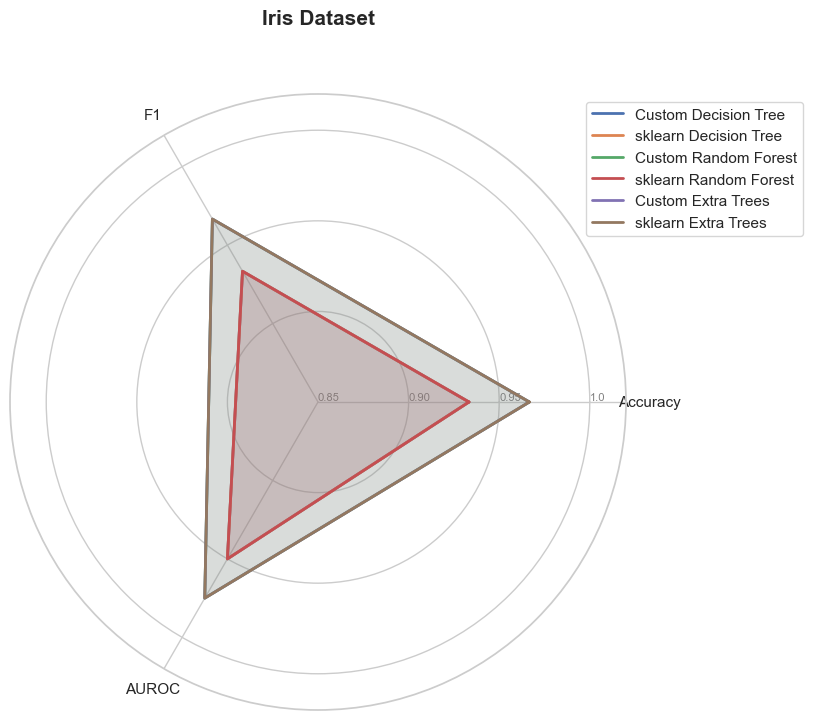

In [214]:
df = pd.DataFrame(results_iris)
df.set_index('Model', inplace=True)
plot_radar_chart(df, title="Iris Dataset")

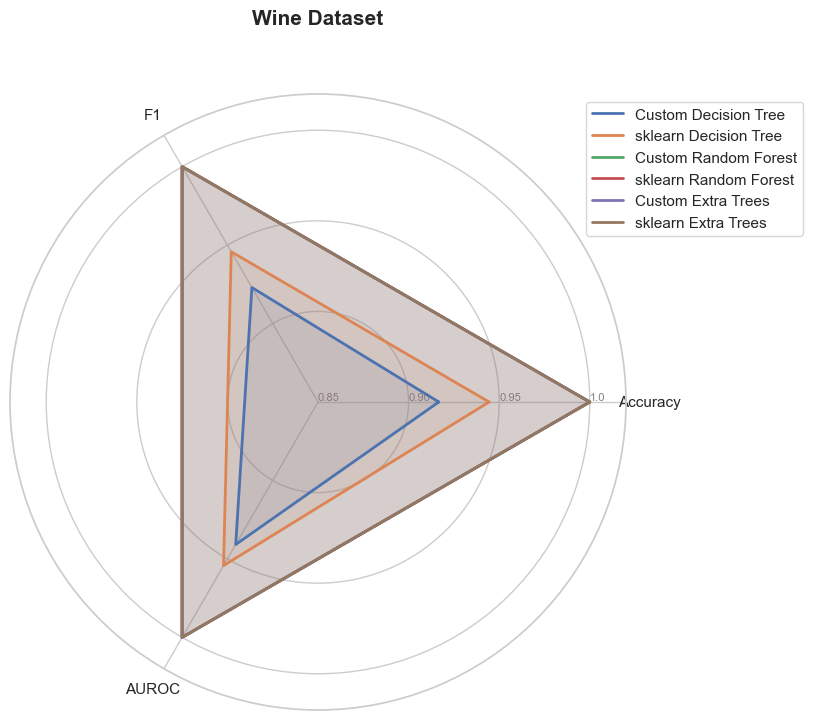

In [215]:
df = pd.DataFrame(results_wine)
df.set_index('Model', inplace=True)
plot_radar_chart(df, title="Wine Dataset")

In [223]:
def plot_depth_sensitivity(X_train, X_test, y_train, y_test, depths=range(1, 11), dsetName = "Iris"):
    manual_acc, sk_acc = [], []
    for d in depths:
        # Manual
        dt = DecisionTree(max_depth=d)
        dt.fit(X_train, y_train)
        manual_acc.append(accuracy_score(y_test, dt.predict(X_test)))
        
        # sklearn
        dt_sk = DecisionTreeClassifier(max_depth=d, random_state=42)
        dt_sk.fit(X_train, y_train)
        sk_acc.append(accuracy_score(y_test, dt_sk.predict(X_test)))

    plt.figure(figsize=(8, 5))
    plt.plot(depths, manual_acc, 'o-', label='Manual DT', color="#a97e19")
    plt.plot(depths, sk_acc, 's--', label='sklearn DT', color='#91416e')
    plt.title(f"Effect of Max Depth on Accuracy ({dsetName} Dataset)")
    plt.xlabel("Max Depth")
    plt.ylabel("Accuracy")
    plt.xticks(depths)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

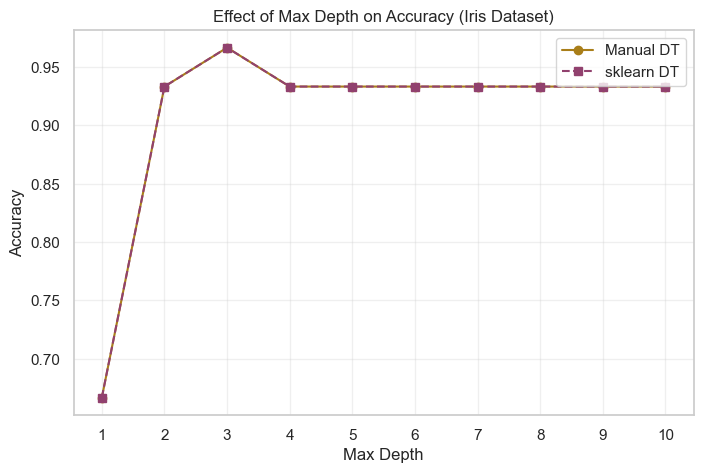

In [224]:
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

plot_depth_sensitivity(X_train, X_test, y_train, y_test, depths=range(1, 11), dsetName="Iris")

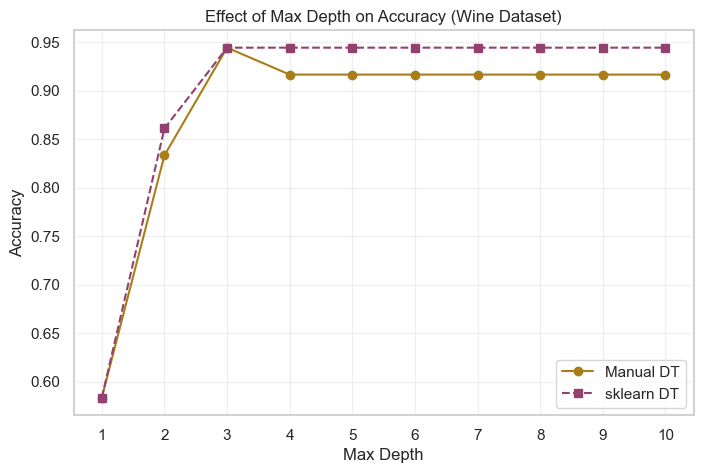

In [225]:
X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

plot_depth_sensitivity(X_train, X_test, y_train, y_test, depths=range(1, 11), dsetName="Wine")

In [229]:
def plot_rf_n_estimators(X_train, X_test, y_train, y_test, n_estimators_list, dsetName="Iris"):
    acc_manual, acc_sklearn = [], []

    for n in n_estimators_list:
        rf = RandomForest(n_trees=n, max_depth=None,
                          max_features=int(np.sqrt(X_train.shape[1])))
        rf.fit(X_train, y_train)
        preds = rf.predict(X_test)
        acc_manual.append(accuracy_score(y_test, preds))

        rf_sk = RandomForestClassifier(n_estimators=n, max_depth=None,
                                       max_features="sqrt", random_state=42)
        rf_sk.fit(X_train, y_train)
        preds_sk = rf_sk.predict(X_test)
        acc_sklearn.append(accuracy_score(y_test, preds_sk))

    plt.figure(figsize=(8,6))
    plt.plot(n_estimators_list, acc_manual, marker='o', label='Custom RF', color="#BA7A03")
    plt.plot(n_estimators_list, acc_sklearn, marker='s', label='sklearn RF', color="#91416e")
    # plt.plot(depths, manual_acc, 'o-', label='Manual DT', color="#a97e19")
    # plt.plot(depths, sk_acc, 's--', label='sklearn DT', color='#91416e')
    # plt.xlabel("Number of Trees")
    plt.ylabel("Accuracy")
    plt.title(f"Random Forest: Effect of n_estimators ({dsetName} Dataset)")
    plt.legend()
    plt.show()


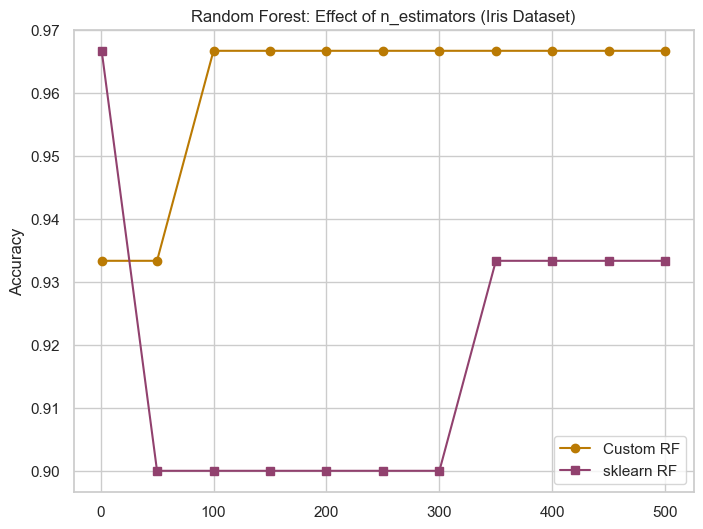

In [238]:
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

plot_rf_n_estimators(X_train, X_test, y_train, y_test, n_estimators_list=[1,50,100,150,200,250,300,350,400,450,500], dsetName="Iris")

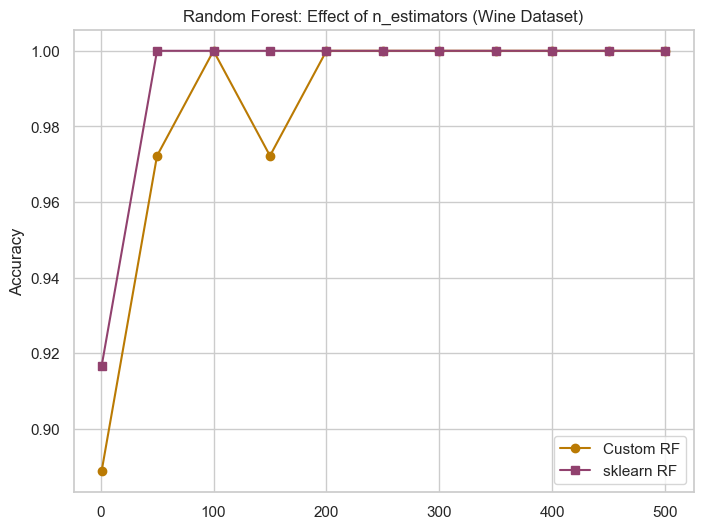

In [239]:
X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

plot_rf_n_estimators(X_train, X_test, y_train, y_test, n_estimators_list=[1,50,100,150,200,250,300,350,400,450,500], dsetName="Wine")